# Crochet Pattern ML - Data Exploration

This notebook explores the Ravelry pattern dataset to understand 
the data and identify useful features for difficulty classification.

## Dataset
- Source: Ravelry API
- Target variable: `difficulty_average`
- Goal: Classify patterns into Easy / Medium / Hard

In [33]:
# Import libraries for data exploration
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pattern_details = pd.read_csv("../data/raw/patterns_raw.csv")
pattern_details.head(5)

,comments_count,created_at,currency,difficulty_average,difficulty_count,downloadable,favorites_count,free,gauge,gauge_divisor,...,languages,packs,printings,yarn_weight,craft,pattern_categories,pattern_attributes,pattern_author,photos,pattern_type
0,8,2019/12/10 00:36:21 -0500,USD,2.998208,558,True,15023,True,NaN,NaN,...,"[{'code': 'en', 'id': 1, 'name': 'English', 'p...","[{'id': 130530934, 'primary_pack_id': None, 'p...","[{'created_at': '2025/03/31 13:43:18 -0400', '...","{'crochet_gauge': None, 'id': 11, 'knit_gauge'...","{'id': 1, 'name': 'Crochet', 'permalink': 'cro...","[{'id': 451, 'name': 'Throw', 'permalink': 'th...","[{'id': 57, 'permalink': 'chevron'}, {'id': 70...","{'crochet_pattern_count': 71, 'favorites_count...","[{'id': 137898669, 'sort_order': 1, 'user_id':...","{'clothing': False, 'id': 11, 'name': 'Blanket..."
1,157,2010/09/18 14:40:44 -0400,NaN,2.160018,2181,True,43324,True,15.0,4.0,...,"[{'code': 'en', 'id': 1, 'name': 'English', 'p...","[{'id': 13207372, 'primary_pack_id': None, 'pr...","[{'created_at': '2010/09/18 14:40:44 -0400', '...","{'crochet_gauge': '', 'id': 1, 'knit_gauge': '...","{'id': 1, 'name': 'Crochet', 'permalink': 'cro...","[{'id': 886, 'name': 'Baby Blanket', 'permalin...","[{'id': 69, 'permalink': 'ripple'}, {'id': 251...","{'crochet_pattern_count': 3, 'favorites_count'...","[{'id': 13201877, 'sort_order': 1, 'user_id': ...","{'clothing': False, 'id': 11, 'name': 'Blanket..."
2,34,2020/08/23 09:03:10 -0400,USD,1.921833,371,True,28760,True,9.5,4.0,...,"[{'code': 'en', 'id': 1, 'name': 'English', 'p...","[{'id': 113847331, 'primary_pack_id': None, 'p...","[{'created_at': '2020/08/23 09:03:10 -0400', '...","{'crochet_gauge': None, 'id': 16, 'knit_gauge'...","{'id': 1, 'name': 'Crochet', 'permalink': 'cro...","[{'id': 470, 'name': 'Containers', 'permalink'...","[{'id': 204, 'permalink': 'one-piece'}, {'id':...","{'crochet_pattern_count': 37, 'favorites_count...","[{'id': 96776611, 'sort_order': 1, 'user_id': ...","{'clothing': False, 'id': 21, 'name': 'Home', ..."
3,11,2023/10/17 22:28:24 -0400,USD,2.509804,153,True,13314,True,NaN,NaN,...,"[{'code': 'en', 'id': 1, 'name': 'English', 'p...","[{'id': 117847529, 'primary_pack_id': None, 'p...","[{'created_at': '2023/10/17 22:28:24 -0400', '...","{'crochet_gauge': None, 'id': 12, 'knit_gauge'...","{'id': 1, 'name': 'Crochet', 'permalink': 'cro...","[{'id': 530, 'name': 'Animal', 'permalink': 'a...","[{'id': 205, 'permalink': 'seamless'}, {'id': ...","{'crochet_pattern_count': 422, 'favorites_coun...","[{'id': 124740627, 'sort_order': 1, 'user_id':...","{'clothing': False, 'id': 16, 'name': 'Toys', ..."
4,53,2024/03/26 12:30:10 -0400,USD,3.294737,190,True,15073,False,22.0,4.0,...,"[{'code': 'en', 'id': 1, 'name': 'English', 'p...","[{'id': 121875815, 'primary_pack_id': None, 'p...","[{'created_at': '2024/03/26 12:30:10 -0400', '...","{'crochet_gauge': None, 'id': 11, 'knit_gauge'...","{'id': 1, 'name': 'Crochet', 'permalink': 'cro...","[{'id': 304, 'name': 'Cardigan', 'permalink': ...","[{'id': 86, 'permalink': 'seamed'}, {'id': 257...","{'crochet_pattern_count': 1, 'favorites_count'...","[{'id': 128954019, 'sort_order': 1, 'user_id':...","{'clothing': True, 'id': 7, 'name': 'Cardigan'..."


In [4]:
pattern_details.shape

(100, 56)

In [5]:
pattern_details.columns

Index(['comments_count', 'created_at', 'currency', 'difficulty_average',
       'difficulty_count', 'downloadable', 'favorites_count', 'free', 'gauge',
       'gauge_divisor', 'gauge_pattern', 'gauge_repeats',
       'generally_available', 'has_uk_terminology', 'has_us_terminology', 'id',
       'name', 'pdf_url', 'permalink', 'price', 'projects_count', 'published',
       'queued_projects_count', 'rating_average', 'rating_count', 'row_gauge',
       'updated_at', 'url', 'yardage', 'yardage_max', 'yarn_list_type',
       'personal_attributes', 'sizes_available', 'product_id',
       'unlisted_product_ids', 'currency_symbol', 'ravelry_download',
       'download_location', 'pdf_in_library', 'volumes_in_library',
       'gauge_description', 'yarn_weight_description', 'yardage_description',
       'pattern_needle_sizes', 'notes_html', 'notes', 'languages', 'packs',
       'printings', 'yarn_weight', 'craft', 'pattern_categories',
       'pattern_attributes', 'pattern_author', 'photos', 'p

In [6]:
pattern_details.describe()

,comments_count,difficulty_average,difficulty_count,favorites_count,gauge,gauge_divisor,gauge_repeats,id,price,projects_count,...,rating_average,rating_count,row_gauge,yardage,yardage_max,yarn_list_type,personal_attributes,product_id,unlisted_product_ids,volumes_in_library
count,100.000000,100.000000,100.000000,100.00000,33.000000,83.000000,1.0,1.000000e+02,51.000000,100.000000,...,100.000000,100.000000,28.000000,69.000000,66.000000,92.000000,0.0,7.100000e+01,0.0,0.0
mean,31.630000,2.709495,362.410000,14077.56000,12.136364,3.771084,4.0,2.611010e+06,6.338431,1586.270000,...,4.787860,367.240000,11.392857,733.347826,1119.666667,1.195652,NaN,7.271837e+05,NaN,NaN
std,45.771425,0.845565,593.312208,11970.13969,6.252840,0.770260,NaN,2.928840e+06,2.451224,2255.490557,...,0.141997,582.771714,6.909946,1028.275067,1632.046081,0.398876,NaN,2.529001e+05,NaN,NaN
min,0.000000,1.440546,15.000000,654.00000,0.000000,1.000000,4.0,4.396000e+03,2.000000,124.000000,...,3.962025,15.000000,1.500000,0.000000,20.000000,1.000000,NaN,1.617800e+04,NaN,NaN
25%,4.000000,2.141147,77.500000,4696.25000,7.500000,4.000000,4.0,7.803058e+05,5.000000,409.000000,...,4.732925,81.500000,6.750000,80.000000,171.250000,1.000000,NaN,5.142675e+05,NaN,NaN
50%,11.000000,2.578393,154.500000,10208.00000,14.000000,4.000000,4.0,1.105796e+06,6.000000,723.000000,...,4.808608,161.000000,11.000000,257.000000,344.000000,1.000000,NaN,7.892260e+05,NaN,NaN
75%,42.250000,3.110033,344.750000,19205.50000,16.000000,4.000000,4.0,7.295633e+06,7.500000,1686.250000,...,4.870650,363.500000,13.250000,1006.000000,1480.500000,1.000000,NaN,9.421675e+05,NaN,NaN
max,257.000000,5.965116,3165.000000,67792.00000,24.000000,4.000000,4.0,7.496458e+06,17.980000,11053.000000,...,4.961039,3064.000000,33.000000,4984.000000,9970.000000,2.000000,NaN,1.051408e+06,NaN,NaN


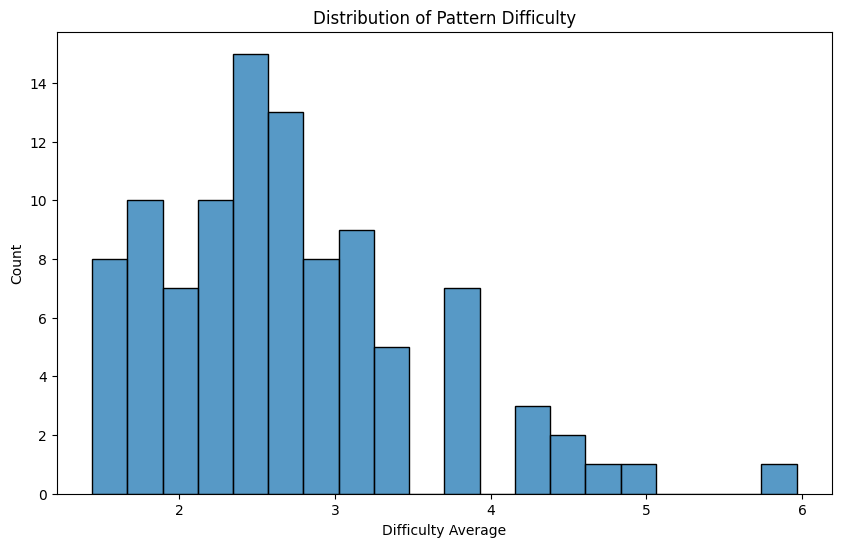

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(pattern_details['difficulty_average'].dropna(), bins=20)
plt.title('Distribution of Pattern Difficulty')
plt.xlabel('Difficulty Average')
plt.ylabel('Count')
plt.show()

In [ ]:
missing_value_percentage = (pattern_details.isnull().sum()/len(pattern_details)) * 100

In [13]:
missing_value_percentage[missing_value_percentage > 0].sort_values(ascending=False)

personal_attributes        100.0
volumes_in_library         100.0
unlisted_product_ids       100.0
pdf_url                     99.0
gauge_repeats               99.0
has_uk_terminology          81.0
gauge_pattern               73.0
row_gauge                   72.0
gauge                       67.0
gauge_description           61.0
price                       49.0
sizes_available             42.0
yardage_max                 34.0
yardage                     31.0
currency_symbol             29.0
product_id                  29.0
currency                    29.0
url                         28.0
gauge_divisor               17.0
yarn_list_type               8.0
has_us_terminology           6.0
published                    5.0
notes                        4.0
notes_html                   4.0
generally_available          1.0
download_location            1.0
yarn_weight_description      1.0
yarn_weight                  1.0
dtype: float64

In [15]:
to_drop = missing_value_percentage[missing_value_percentage > 50]
df_clean  = pattern_details.drop(columns=to_drop.index)

## Data Cleaning

Dropping columns with more than 50% missing values as they 
won't be useful for model training.

In [18]:
print("Before cleaning:", pattern_details.shape)
print("After cleaning:", df_clean.shape)

Before cleaning: (100, 56)
After cleaning: (100, 46)


In [19]:
df_clean.columns.tolist()

['comments_count',
 'created_at',
 'currency',
 'difficulty_average',
 'difficulty_count',
 'downloadable',
 'favorites_count',
 'free',
 'gauge_divisor',
 'generally_available',
 'has_us_terminology',
 'id',
 'name',
 'permalink',
 'price',
 'projects_count',
 'published',
 'queued_projects_count',
 'rating_average',
 'rating_count',
 'updated_at',
 'url',
 'yardage',
 'yardage_max',
 'yarn_list_type',
 'sizes_available',
 'product_id',
 'currency_symbol',
 'ravelry_download',
 'download_location',
 'pdf_in_library',
 'yarn_weight_description',
 'yardage_description',
 'pattern_needle_sizes',
 'notes_html',
 'notes',
 'languages',
 'packs',
 'printings',
 'yarn_weight',
 'craft',
 'pattern_categories',
 'pattern_attributes',
 'pattern_author',
 'photos',
 'pattern_type']

In [59]:
features = [
    'yardage', 'yarn_weight', 'gauge_divisor',
    'favorites_count', 'projects_count', 'rating_average', 
    'rating_count', 'free', 'comments_count', 
    'queued_projects_count', 'pattern_categories',
    'pattern_attributes'
]

target = 'difficulty_average'

In [60]:
df_model = df_clean[features + [target]].copy()


In [61]:
model_missing_value_percentage = (df_model.isnull().sum() / len(df_model)) * 100

In [62]:
model_missing_value_percentage

yardage                  31.0
yarn_weight               1.0
gauge_divisor            17.0
favorites_count           0.0
projects_count            0.0
rating_average            0.0
rating_count              0.0
free                      0.0
comments_count            0.0
queued_projects_count     0.0
pattern_categories        0.0
pattern_attributes        0.0
difficulty_average        0.0
dtype: float64

In [63]:
for column in df_model.columns:
    if df_model[column].dtype == 'object':
        column_mode = df_model[column].mode()[0] 
        df_model[column] = df_model[column].fillna(column_mode)
    else:
        column_median = df_model[column].median()
        df_model[column] = df_model[column].fillna(column_median)

In [64]:
df_model.isnull().sum()

yardage                  0
yarn_weight              0
gauge_divisor            0
favorites_count          0
projects_count           0
rating_average           0
rating_count             0
free                     0
comments_count           0
queued_projects_count    0
pattern_categories       0
pattern_attributes       0
difficulty_average       0
dtype: int64

In [65]:
print(df_model['yarn_weight'].value_counts())

yarn_weight
{'crochet_gauge': None, 'id': 12, 'knit_gauge': '20', 'max_gauge': None, 'min_gauge': None, 'name': 'Worsted', 'ply': '10', 'wpi': '9'}            31
{'crochet_gauge': '', 'id': 1, 'knit_gauge': '18', 'max_gauge': None, 'min_gauge': None, 'name': 'Aran', 'ply': '10', 'wpi': '8'}                  22
{'crochet_gauge': None, 'id': 11, 'knit_gauge': '22', 'max_gauge': None, 'min_gauge': None, 'name': 'DK', 'ply': '8', 'wpi': '11'}                 17
{'crochet_gauge': '', 'id': 6, 'knit_gauge': '7-12', 'max_gauge': None, 'min_gauge': None, 'name': 'Super Bulky', 'ply': None, 'wpi': '5-6'}        8
{'crochet_gauge': '', 'id': 5, 'knit_gauge': '28', 'max_gauge': None, 'min_gauge': None, 'name': 'Fingering', 'ply': '4', 'wpi': '14'}              8
{'crochet_gauge': '', 'id': 4, 'knit_gauge': '14-15', 'max_gauge': None, 'min_gauge': None, 'name': 'Bulky', 'ply': '12', 'wpi': '7'}               4
{'crochet_gauge': None, 'id': 10, 'knit_gauge': '24-26', 'max_gauge': None, 'min_gauge':

In [66]:
df_model['yarn_weight'] = df_model['yarn_weight'].apply(lambda x: ast.literal_eval(x)['name'] if pd.notna(x) else None)

In [67]:
print(df_model['yarn_weight'].value_counts())

yarn_weight
Worsted            31
Aran               22
DK                 17
Super Bulky         8
Fingering           8
Bulky               4
Sport               3
Jumbo               2
Any gauge           2
Light Fingering     2
Thread              1
Name: count, dtype: int64


In [68]:
print(df_model['pattern_categories'].iloc[0])

[{'id': 451, 'name': 'Throw', 'permalink': 'throw', 'parent': {'id': 450, 'name': 'Blanket', 'permalink': 'blanket', 'parent': {'id': 449, 'name': 'Home', 'permalink': 'home', 'parent': {'id': 301, 'name': 'Categories', 'permalink': 'categories'}}}}, {'id': 886, 'name': 'Baby Blanket', 'permalink': 'babyblanket', 'parent': {'id': 450, 'name': 'Blanket', 'permalink': 'blanket', 'parent': {'id': 449, 'name': 'Home', 'permalink': 'home', 'parent': {'id': 301, 'name': 'Categories', 'permalink': 'categories'}}}}]


In [69]:
def extract_category(x):
    """Extract top level category from nested pattern categories."""
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)[0]['parent']['parent']['name']
    except Exception:
        return None
df_model['pattern_categories'] = df_model['pattern_categories'].apply(extract_category)


In [71]:
print(df_model['pattern_categories'].value_counts())

pattern_categories
Accessories         34
Home                24
Toys and Hobbies    24
Categories           9
Clothing             9
Name: count, dtype: int64


In [72]:
print(df_model['pattern_attributes'].iloc[0])


[{'id': 57, 'permalink': 'chevron'}, {'id': 70, 'permalink': 'textured'}, {'id': 251, 'permalink': 'star-shaped'}, {'id': 267, 'permalink': 'written-pattern'}, {'id': 268, 'permalink': 'video-tutorial'}, {'id': 286, 'permalink': 'in-the-round'}, {'id': 266, 'permalink': 'phototutorial'}, {'id': 4, 'permalink': 'baby'}, {'id': 69, 'permalink': 'ripple'}, {'id': 265, 'permalink': 'chart'}]


In [73]:
def count_attributes(x):
    if pd.isna(x):
        return None
    return len(ast.literal_eval(x))
df_model['pattern_attributes'] = df_model['pattern_attributes'].apply(count_attributes)
print(df_model['pattern_attributes'].describe())


count    100.000000
mean       5.850000
std        3.270236
min        1.000000
25%        3.000000
50%        5.000000
75%        8.000000
max       14.000000
Name: pattern_attributes, dtype: float64


In [74]:
print(df_model.dtypes)


yardage                  float64
yarn_weight               object
gauge_divisor            float64
favorites_count            int64
projects_count             int64
rating_average           float64
rating_count               int64
free                        bool
comments_count             int64
queued_projects_count      int64
pattern_categories        object
pattern_attributes         int64
difficulty_average       float64
dtype: object


In [76]:
pd.get_dummies(df_model[['yarn_weight', 'pattern_categories']], dtype=int)

,yarn_weight_Any gauge,yarn_weight_Aran,yarn_weight_Bulky,yarn_weight_DK,yarn_weight_Fingering,yarn_weight_Jumbo,yarn_weight_Light Fingering,yarn_weight_Sport,yarn_weight_Super Bulky,yarn_weight_Thread,yarn_weight_Worsted,pattern_categories_Accessories,pattern_categories_Categories,pattern_categories_Clothing,pattern_categories_Home,pattern_categories_Toys and Hobbies
0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
4,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
96,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
97,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
98,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0


In [77]:
# 1. Convert free to int
df_model['free'] = df_model['free'].astype(int)

# 2. Create dummies
dummies = pd.get_dummies(df_model[['yarn_weight', 'pattern_categories']], dtype=int)

# 3. Drop original columns and join dummies
df_model = df_model.drop(columns=['yarn_weight', 'pattern_categories'])
df_model = pd.concat([df_model, dummies], axis=1)

# 4. Verify
print(df_model.shape)
print(df_model.dtypes)

(100, 27)
yardage                                float64
gauge_divisor                          float64
favorites_count                          int64
projects_count                           int64
rating_average                         float64
rating_count                             int64
free                                     int64
comments_count                           int64
queued_projects_count                    int64
pattern_attributes                       int64
difficulty_average                     float64
yarn_weight_Any gauge                    int64
yarn_weight_Aran                         int64
yarn_weight_Bulky                        int64
yarn_weight_DK                           int64
yarn_weight_Fingering                    int64
yarn_weight_Jumbo                        int64
yarn_weight_Light Fingering              int64
yarn_weight_Sport                        int64
yarn_weight_Super Bulky                  int64
yarn_weight_Thread                       int64
yar

In [ ]:
df_model.to_csv('../data/processed/patterns_processed.csv', index=False)
print("Processed data saved!")
